# MD13003 - Advanced Predictive Analytics Laboratory 01
## End-to-End Predictive Analytics Pipeline with Kaggle Housing Dataset

**Student Registration Number:** `23MID0078`  
**Course Code:** `MD13003`  
**Global Seed:** `SEED = 42`  

---
### Overview & Objectives
1. **Data Ingestion & EDA** - target distribution & correlation heatmap
2. **Leak-Proof Preprocessing** - `ColumnTransformer` & `Pipeline`
3. **Multi-Model Evaluation** - RandomForest, GradientBoosting, Ridge
4. **5-Fold Cross-Validation** analysis
5. **Feature Importance & Residual Analysis**
6. **Artifact Export** to `output/` directory

## Section 1: Environment Setup & Output Directory Initialization

In [1]:
import os
import json
import datetime
import platform
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

REGISTRATION_NO = '23MID0078'
SEED = 42
np.random.seed(SEED)

for folder in ['output/tables', 'output/figures', 'output/models', 'output/metadata']:
    os.makedirs(folder, exist_ok=True)

print(f'[{REGISTRATION_NO}] Directories initialized. SEED = {SEED}')

[23MID0078] Directories initialized. SEED = 42


## Section 2: Data Ingestion & Exploratory Data Analysis (EDA)

Dataset Shape: (40, 8)
       square_feet  age_years  num_rooms  distance_km     price_k
count    40.000000  40.000000  40.000000    40.000000   40.000000
mean   1930.350000  11.625000   3.100000     8.695000  300.281250
std     732.037679   7.899002   1.150251     5.895324   93.503006
min     880.000000   1.000000   1.000000     1.200000  155.200000
25%    1372.500000   4.000000   2.000000     3.725000  204.675000
50%    1775.250000  10.500000   3.000000     7.800000  309.125000
75%    2525.000000  19.000000   4.000000    12.525000  372.125000
max    3300.000000  28.000000   5.000000    22.500000  445.600000


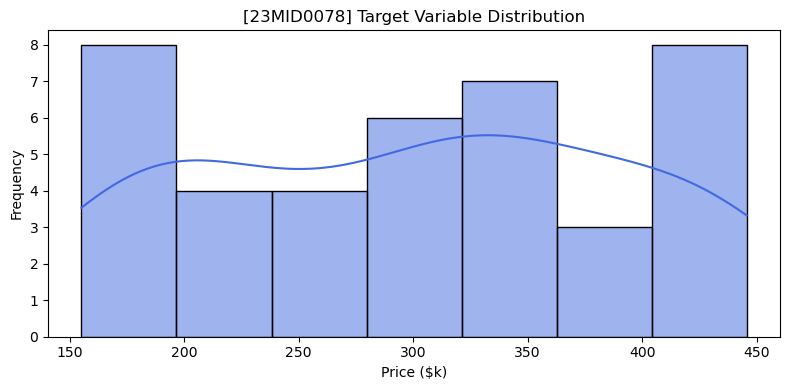

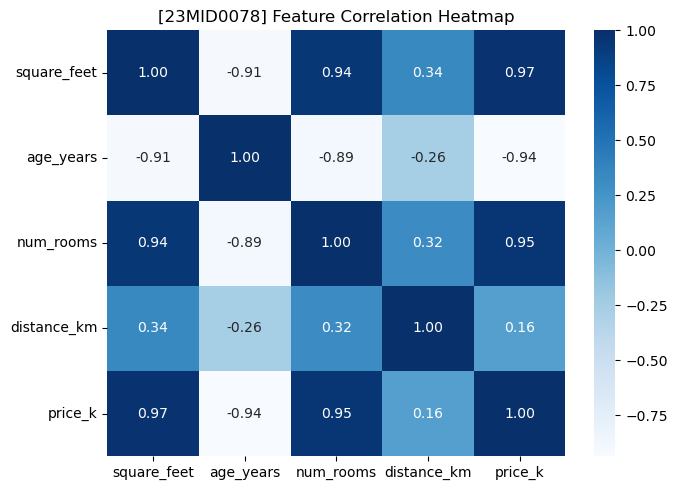

In [2]:
dataset_path = 'datasets/kaggle_housing_predictive_dataset.csv'
df = pd.read_csv(dataset_path)
print('Dataset Shape:', df.shape)
print(df.describe())

plt.figure(figsize=(8, 4))
sns.histplot(df['price_k'], kde=True, color='royalblue')
plt.title(f'[{REGISTRATION_NO}] Target Variable Distribution')
plt.xlabel('Price ($k)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('output/figures/23MID0078_Target_Distribution.png', dpi=300)
plt.show()

plt.figure(figsize=(7, 5))
num_df = df.select_dtypes(include=[np.number])
sns.heatmap(num_df.corr(), annot=True, cmap='Blues', fmt='.2f')
plt.title(f'[{REGISTRATION_NO}] Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('output/figures/23MID0078_Correlation_Heatmap.png', dpi=300)
plt.show()

## Section 3: Data Preprocessing & ColumnTransformer Assembly

In [3]:
X = df.drop(columns=['price_k'])
y = df['price_k']

num_cols = ['square_feet', 'age_years', 'num_rooms', 'distance_km']
cat_cols = ['location_code', 'property_type', 'energy_rating']

num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', num_pipeline, num_cols),
    ('cat', cat_pipeline, cat_cols)
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (32, 7), Test: (8, 7)


## Section 4: Multi-Model Training & Evaluation

                       Model Registration_No     MAE      MSE    RMSE  \
0      RandomForestRegressor       23MID0078  3.7557  20.1836  4.4926   
1  GradientBoostingRegressor       23MID0078  4.5759  25.3424  5.0341   
2             RidgeRegressor       23MID0078  5.8506  44.1408  6.6439   

   R2_Score  
0    0.9956  
1    0.9945  
2    0.9904  


C:\Users\mribl\AppData\Local\Temp\ipykernel_17876\203443544.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x='Model', y='R2_Score', palette='viridis')


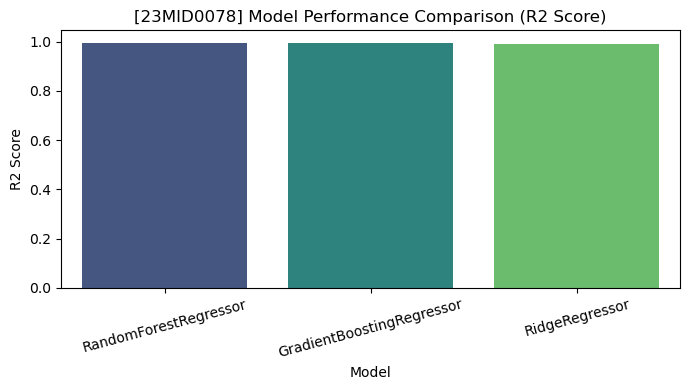

In [4]:
models = {
    'RandomForestRegressor': RandomForestRegressor(n_estimators=100, random_state=SEED),
    'GradientBoostingRegressor': GradientBoostingRegressor(n_estimators=100, random_state=SEED),
    'RidgeRegressor': Ridge(random_state=SEED)
}

results_list = []
fitted_pipelines = {}

for name, estimator in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('regressor', estimator)])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    fitted_pipelines[name] = pipe
    results_list.append({'Model': name, 'Registration_No': REGISTRATION_NO,
                         'MAE': round(mae, 4), 'MSE': round(mse, 4),
                         'RMSE': round(rmse, 4), 'R2_Score': round(r2, 4)})

comparison_df = pd.DataFrame(results_list)
comparison_df.to_csv('output/tables/23MID0078_Lab01_Model_Comparison.csv', index=False)
print(comparison_df)

plt.figure(figsize=(7, 4))
sns.barplot(data=comparison_df, x='Model', y='R2_Score', palette='viridis')
plt.title(f'[{REGISTRATION_NO}] Model Performance Comparison (R2 Score)')
plt.ylabel('R2 Score')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('output/figures/23MID0078_Model_Comparison_Chart.png', dpi=300)
plt.show()

## Section 5: 5-Fold Cross-Validation Analysis

In [5]:
best_model_name = comparison_df.sort_values(by='R2_Score', ascending=False).iloc[0]['Model']
best_pipeline = fitted_pipelines[best_model_name]
print(f'Best model: {best_model_name}')

cv_results = cross_validate(
    best_pipeline, X_train, y_train, cv=5,
    scoring=['neg_mean_absolute_error', 'neg_mean_squared_error', 'neg_root_mean_squared_error', 'r2']
)

cv_df = pd.DataFrame({
    'Fold': [f'Fold_{i+1}' for i in range(5)],
    'Registration_No': REGISTRATION_NO,
    'Fold_MAE': np.round(-cv_results['test_neg_mean_absolute_error'], 4),
    'Fold_MSE': np.round(-cv_results['test_neg_mean_squared_error'], 4),
    'Fold_RMSE': np.round(-cv_results['test_neg_root_mean_squared_error'], 4),
    'Fold_R2': np.round(cv_results['test_r2'], 4)
})
cv_df.to_csv('output/tables/23MID0078_Lab01_CV_Results.csv', index=False)
print(cv_df)

Best model: RandomForestRegressor
     Fold Registration_No  Fold_MAE  Fold_MSE  Fold_RMSE  Fold_R2
0  Fold_1       23MID0078    6.9436   55.9427     7.4795   0.9929
1  Fold_2       23MID0078    8.7546  106.0544    10.2983   0.9895
2  Fold_3       23MID0078   10.6621  194.3182    13.9398   0.9417
3  Fold_4       23MID0078    5.5629   53.1924     7.2933   0.9937
4  Fold_5       23MID0078   14.4531  214.0623    14.6309   0.9840


## Section 6: Feature Importances & Residual Plotting

C:\Users\mribl\AppData\Local\Temp\ipykernel_17876\3980735003.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_df, x='Importance', y='Feature', palette='mako')


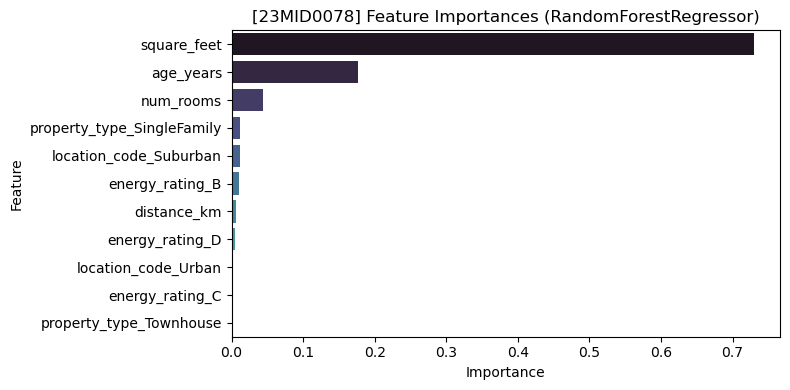

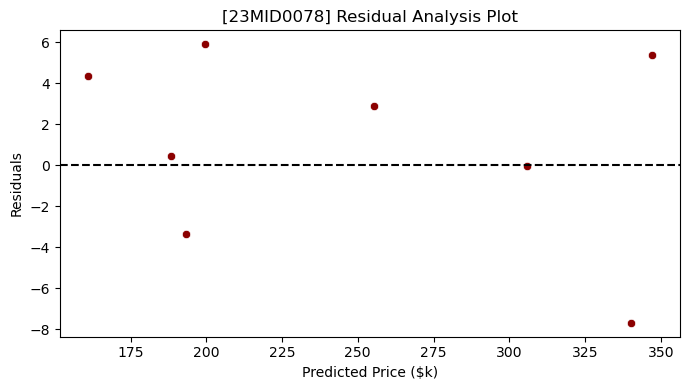

In [6]:
ohe_cols = list(
    best_pipeline.named_steps['preprocessor']
    .named_transformers_['cat']
    .named_steps['encoder']
    .get_feature_names_out(cat_cols)
)
all_features = num_cols + ohe_cols

if hasattr(best_pipeline.named_steps['regressor'], 'feature_importances_'):
    importances = best_pipeline.named_steps['regressor'].feature_importances_
    feat_df = pd.DataFrame({'Feature': all_features, 'Importance': importances})
    feat_df = feat_df.sort_values(by='Importance', ascending=False)
    feat_df.to_csv('output/tables/23MID0078_Lab01_Feature_Importances.csv', index=False)
    plt.figure(figsize=(8, 4))
    sns.barplot(data=feat_df, x='Importance', y='Feature', palette='mako')
    plt.title(f'[{REGISTRATION_NO}] Feature Importances ({best_model_name})')
    plt.tight_layout()
    plt.savefig('output/figures/23MID0078_Feature_Importances_Chart.png', dpi=300)
    plt.show()

y_pred_best = best_pipeline.predict(X_test)
residuals = y_test - y_pred_best
plt.figure(figsize=(7, 4))
sns.scatterplot(x=y_pred_best, y=residuals, color='darkred')
plt.axhline(0, color='black', linestyle='--')
plt.title(f'[{REGISTRATION_NO}] Residual Analysis Plot')
plt.xlabel('Predicted Price ($k)')
plt.ylabel('Residuals')
plt.tight_layout()
plt.savefig('output/figures/23MID0078_Residuals_Plot.png', dpi=300)
plt.show()

## Section 7: Model Serialization & Run Metadata Export

In [7]:
model_path = 'output/models/23MID0078_Best_Model_Pipeline.joblib'
joblib.dump(best_pipeline, model_path)

run_metadata = {
    'registration_number': REGISTRATION_NO,
    'course_code': 'MD13003 - Advanced Predictive Analytics',
    'execution_timestamp': datetime.datetime.now(datetime.timezone.utc).isoformat(),
    'seed': SEED,
    'environment': {
        'python_version': platform.python_version(),
        'platform': platform.platform(),
    },
    'dataset': {
        'path': dataset_path,
        'samples': len(df),
        'features': X.shape[1],
    },
    'best_model': best_model_name,
    'test_metrics': comparison_df[
        comparison_df['Model'] == best_model_name
    ].to_dict(orient='records')[0],
}

with open('output/metadata/23MID0078_Run_Metadata.json', 'w') as f:
    json.dump(run_metadata, f, indent=4)

print(f'Model saved to: {model_path}')
print('Metadata saved to: output/metadata/23MID0078_Run_Metadata.json')
print(f'[{REGISTRATION_NO}] All outputs generated successfully.')

Model saved to: output/models/23MID0078_Best_Model_Pipeline.joblib
Metadata saved to: output/metadata/23MID0078_Run_Metadata.json
[23MID0078] All outputs generated successfully.
